## Phase 1 — Data Understanding

In [2]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv("/Sample - Superstore.csv", encoding='latin1')

# First 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



```
Total rows?
Total columns?
Column names?
Missing values?
```

## Phase 2 — Data Cleaning

In [3]:
# Missing values check
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [4]:
# Duplicate rows check
df.duplicated().sum()

np.int64(0)

In [6]:
# Remove duplicates
df = df.drop_duplicates()

## Phase 3 — Business KPIs

In [9]:
# Total Sales
df["Sales"].sum()

np.float64(2297200.8603000003)

In [10]:
# Total Profit
df["Profit"].sum()

np.float64(286397.0217)

In [11]:
# Total Orders
df["Order ID"].nunique()

5009

In [12]:
# Total Customers
df["Customer ID"].nunique()

793

In [13]:
# Average Discount
df["Discount"].mean()

np.float64(0.15620272163297977)

## Phase 4 — Category Analysis

In [14]:
# Sales by Category
df.groupby("Category")["Sales"].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


Chart:


<Axes: xlabel='Category'>

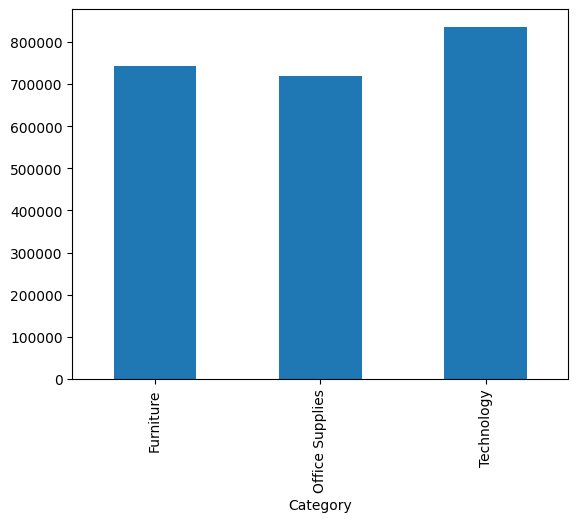

In [16]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales.plot(kind="bar")

Save:


In [18]:
import matplotlib.pyplot as plt

# Save the plot generated in the previous cell
plt.savefig("sales_by_category.png")

<Figure size 640x480 with 0 Axes>

## Phase 5 — Profit Analysis

In [20]:
# Profit by Category
df.groupby("Category")["Profit"].sum()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


Chart save:

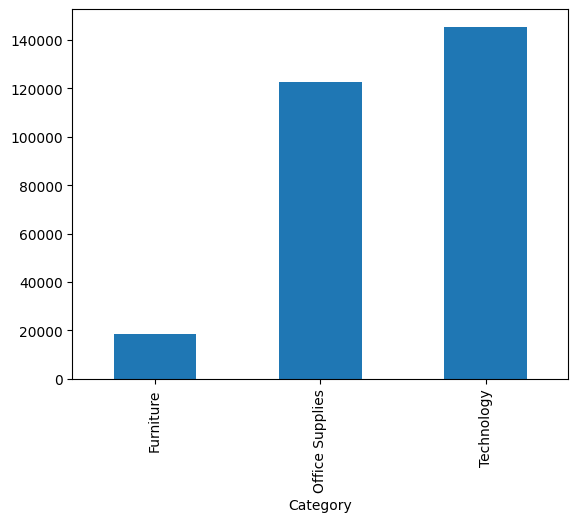

In [22]:
import matplotlib.pyplot as plt

profit_by_category = df.groupby("Category")["Profit"].sum()
profit_by_category.plot(kind="bar")
plt.savefig("profit_by_category.png")

## Phase 7 — Product Analysis


In [23]:
# Top 10 Products
df.groupby("Product Name")["Sales"].sum()

,Sales
Product Name,
"""While you Were Out"" Message Book, One Form per Page",25.228
"#10 Gummed Flap White Envelopes, 100/Box",41.300
#10 Self-Seal White Envelopes,108.682
"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672
...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",477.660
iOttie HLCRIO102 Car Mount,215.892
iOttie XL Car Mount,223.888


Sort descending.

Top 10 chart.

Save:

/tmp/ipykernel_8872/243569960.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


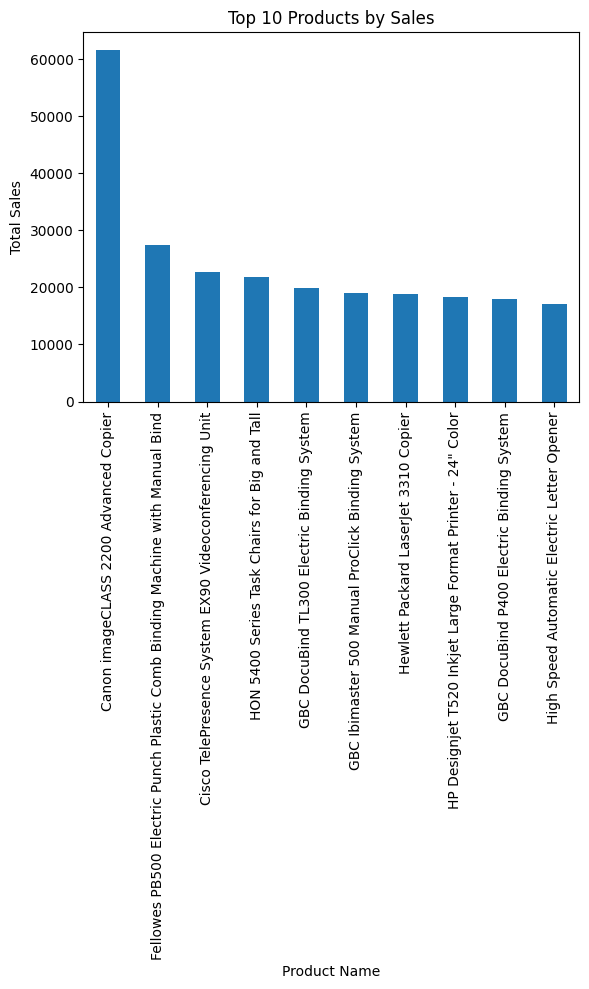

In [25]:
import matplotlib.pyplot as plt

# Calculate sales by product, sort, and get top 10
top_10_products = df.groupby("Product Name")["Sales"].sum().nlargest(10)

# Plot the top 10 products
top_10_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("top_products.png")

## Phase 8 — Time Analysis




In [28]:
# Convert date
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [27]:
# Monthly sales
df.groupby(df["Order Date"].dt.month)["Sales"].sum()

,Sales
Order Date,
1,94924.8356
2,59751.2514
3,205005.4888
4,137762.1286
5,155028.8117
6,152718.6793
7,147238.0970
8,159044.0630
9,307649.9457


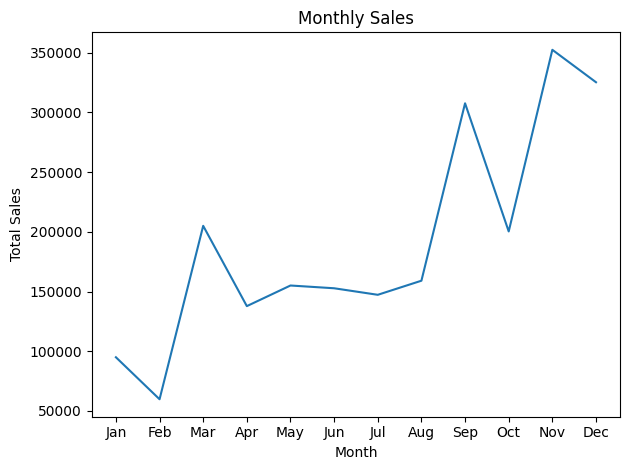

In [30]:
import matplotlib.pyplot as plt

# Calculate monthly sales (assuming 'Order Date' is already converted to datetime)
monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()

# Plot the monthly sales
monthly_sales.plot(kind="line")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("monthly_sales.png")

## Phase 9 — Discount Impact

**Question:**
*   Does a higher discount reduce profit?


**Chart File Name**


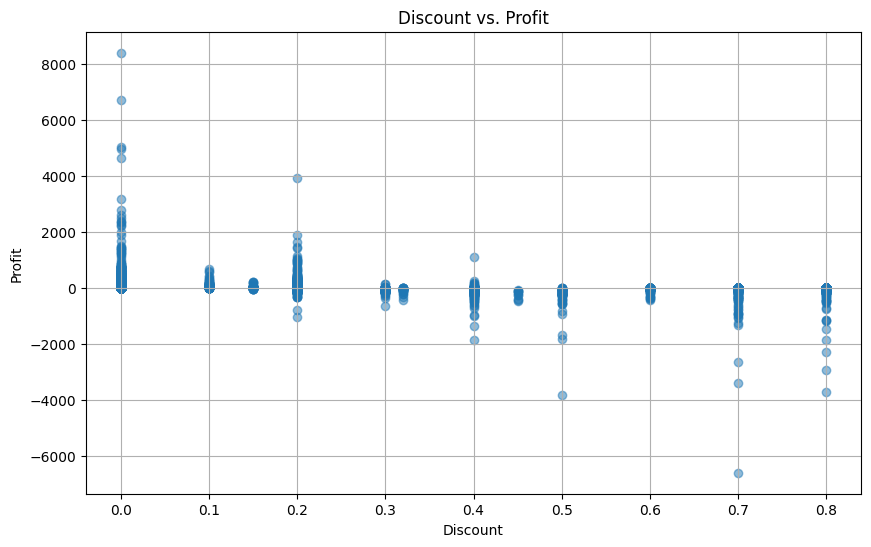

In [33]:
import matplotlib.pyplot as plt

# Create a scatter plot of Discount vs Profit
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title('Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)

# Save the plot
plt.savefig("discount_vs_profit.png")
plt.show()

## Phase 10 — Customer Analysis

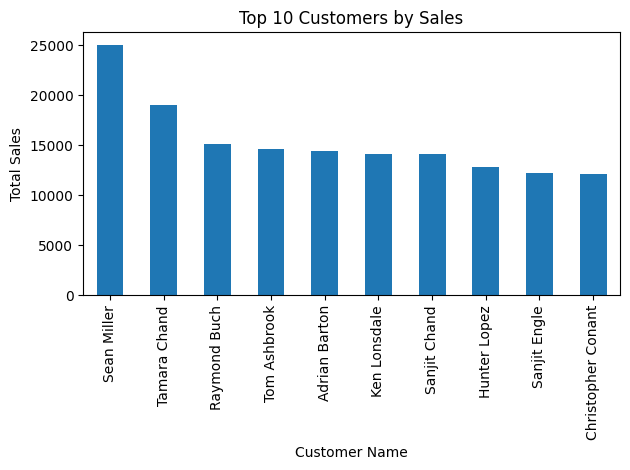

In [34]:
# Top 10 Customers by Sales

top_customers = df.groupby("Customer Name")["Sales"].sum().nlargest(10)

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("top_customers.png")

plt.show()

## Phase 11 — Region Analysis

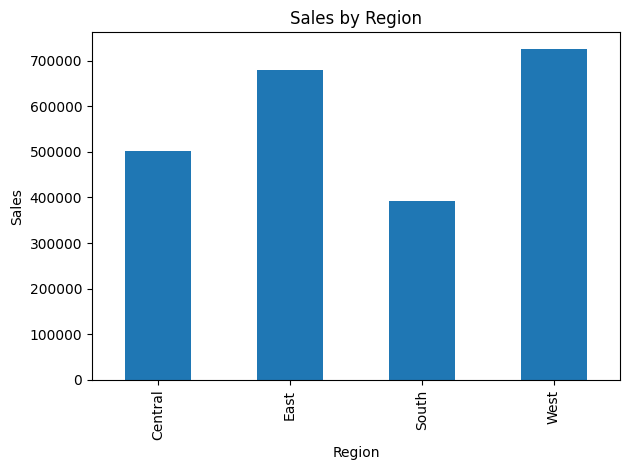

In [35]:
# Sales by Region

region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("region_sales.png")

plt.show()


## Phase 12 — Final Business Insights

# Business Insights

1. Technology category generated highest sales.

2. Technology category generated highest profit.

3. November and December showed peak sales performance.

4. Higher discounts generally reduced profitability.

5. A small number of customers contributed a large share of revenue.

6. Some products generated high sales but low profit.

7. Regional performance varied significantly.

##Conclusion


# Conclusion

This project analyzed Superstore sales data using Python, Pandas, and Matplotlib.

Key findings:

- Technology category delivered the highest revenue and profit.
- Sales peaked during November and December.
- Higher discounts negatively affected profit.
- A few customers contributed significantly to overall sales.
- Regional performance differed across markets.

The analysis can help businesses improve pricing, inventory planning, and customer targeting strategies.